# 04 — Wear Estimation: Monaco GP 2026 Q

Goal of this notebook:
1. Apply the `wear_model` module to the steady-state thermal cycle from notebook 03
2. Report per-lap wear split between mechanical and oxidative mechanisms
3. Visualize where on the lap wear concentrates
4. Note absolute-magnitude calibration gap honestly

This completes the Phase 1a hidden-state estimation chain:
**telemetry → energy → temperature → wear**.

In [1]:
#Setup and recreate the steady-state lap

import sys
sys.path.insert(0, '..')

import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.physics.energy_balance import air_density, decompose_braking_event
from src.physics.thermal_model import build_input_power_per_disc, integrate_lap
from src.physics.wear_model import (
    mechanical_wear_rate, oxidative_wear_rate, integrate_wear_lap
)
from src.utils import constants as C

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

fastf1.Cache.enable_cache('../data/raw')

# Recreate the full chain (compact version of notebooks 02 and 03)
session = fastf1.get_session(2026, 'Monaco', 'Q')
session.load(laps=True, telemetry=True, weather=True, messages=False)
fastest = session.laps.pick_fastest()
tel = fastest.get_telemetry()

T_air_C = session.weather_data['AirTemp'].mean()
T_amb_K = T_air_C + 273.15
rho_air = air_density(T_air_C)

t_lap = tel['Time'].dt.total_seconds().values
v_lap_ms = tel['Speed'].values / 3.6
dist_lap = tel['Distance'].values

brake = tel['Brake'].astype(int).values
edges = np.diff(brake, prepend=0, append=0)
starts = np.where(edges == 1)[0]
ends = np.where(edges == -1)[0] - 1

events = []
for i, (s_idx, e_idx) in enumerate(zip(starts, ends)):
    v_ev = v_lap_ms[s_idx:e_idx + 1]
    t_ev = t_lap[s_idx:e_idx + 1]
    duration = t_ev[-1] - t_ev[0] if len(t_ev) > 1 else 0
    delta_v_kmh = (v_ev[0] - v_ev[-1]) * 3.6
    if duration < 0.1 or delta_v_kmh < 5.0:
        continue
    decomp = decompose_braking_event(v_ev, t_ev, rho_air=rho_air)
    events.append({
        'event_id': i + 1,
        'start_idx': s_idx, 'end_idx': e_idx,
        'E_brake_front_J': decomp['E_brake_front_J'],
    })

P_in = build_input_power_per_disc(t_lap, events)

# Iterate to steady state
T_init_K = 400.0 + 273.15
for _ in range(10):
    T_run = integrate_lap(t_lap, v_lap_ms, P_in, T_amb_K, T_init_K)
    if abs(T_run[-1] - T_run[0]) < 1.0:
        break
    T_init_K = T_run[-1]

T_disc_K = T_run
T_disc_C = T_disc_K - 273.15

print(f"Steady-state thermal cycle ready:")
print(f"  T_min:  {T_disc_C.min():.1f}°C")
print(f"  T_max:  {T_disc_C.max():.1f}°C")
print(f"  T_mean: {T_disc_C.mean():.1f}°C")

core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['12', '3', '44', '16', '6', '63', '81', '1', '10', '30', '23', '55', '27', '43', '41', '5', '31', '11', '87', '77', '14', '18']


Steady-state thermal cycle ready:
  T_min:  566.6°C
  T_max:  798.4°C
  T_mean: 714.7°C


In [2]:
#Compute wear

wear = integrate_wear_lap(t_lap, P_in, T_disc_K)

print("Per-disc wear over the steady-state lap:")
print(f"  Mechanical: {wear['W_mech_kg']*1e6:>8.3f} mg ({wear['W_mech_kg']/wear['W_total_kg']*100:>5.1f}%)")
print(f"  Oxidative:  {wear['W_ox_kg']*1e6:>8.3f} mg ({wear['W_ox_kg']/wear['W_total_kg']*100:>5.1f}%)")
print(f"  Total:      {wear['W_total_mg']:>8.3f} mg")
print(f"")
print(f"  Equivalent thickness loss per disc face: {wear['thickness_loss_um']:.3f} µm")
print(f"")
print(f"Calibration note: real F1 wear is reportedly 15-50 µm per lap per disc.")
print(f"Our model is ~{50/max(wear['thickness_loss_um'], 0.01):.0f}× too low in absolute terms.")
print(f"This is the L-confidence coefficient gap documented in parameter doc §5.5.")

Per-disc wear over the steady-state lap:
  Mechanical:   26.954 mg (100.0%)
  Oxidative:     0.001 mg (  0.0%)
  Total:        26.954 mg

  Equivalent thickness loss per disc face: 0.125 µm

Calibration note: real F1 wear is reportedly 15-50 µm per lap per disc.
Our model is ~401× too low in absolute terms.
This is the L-confidence coefficient gap documented in parameter doc §5.5.


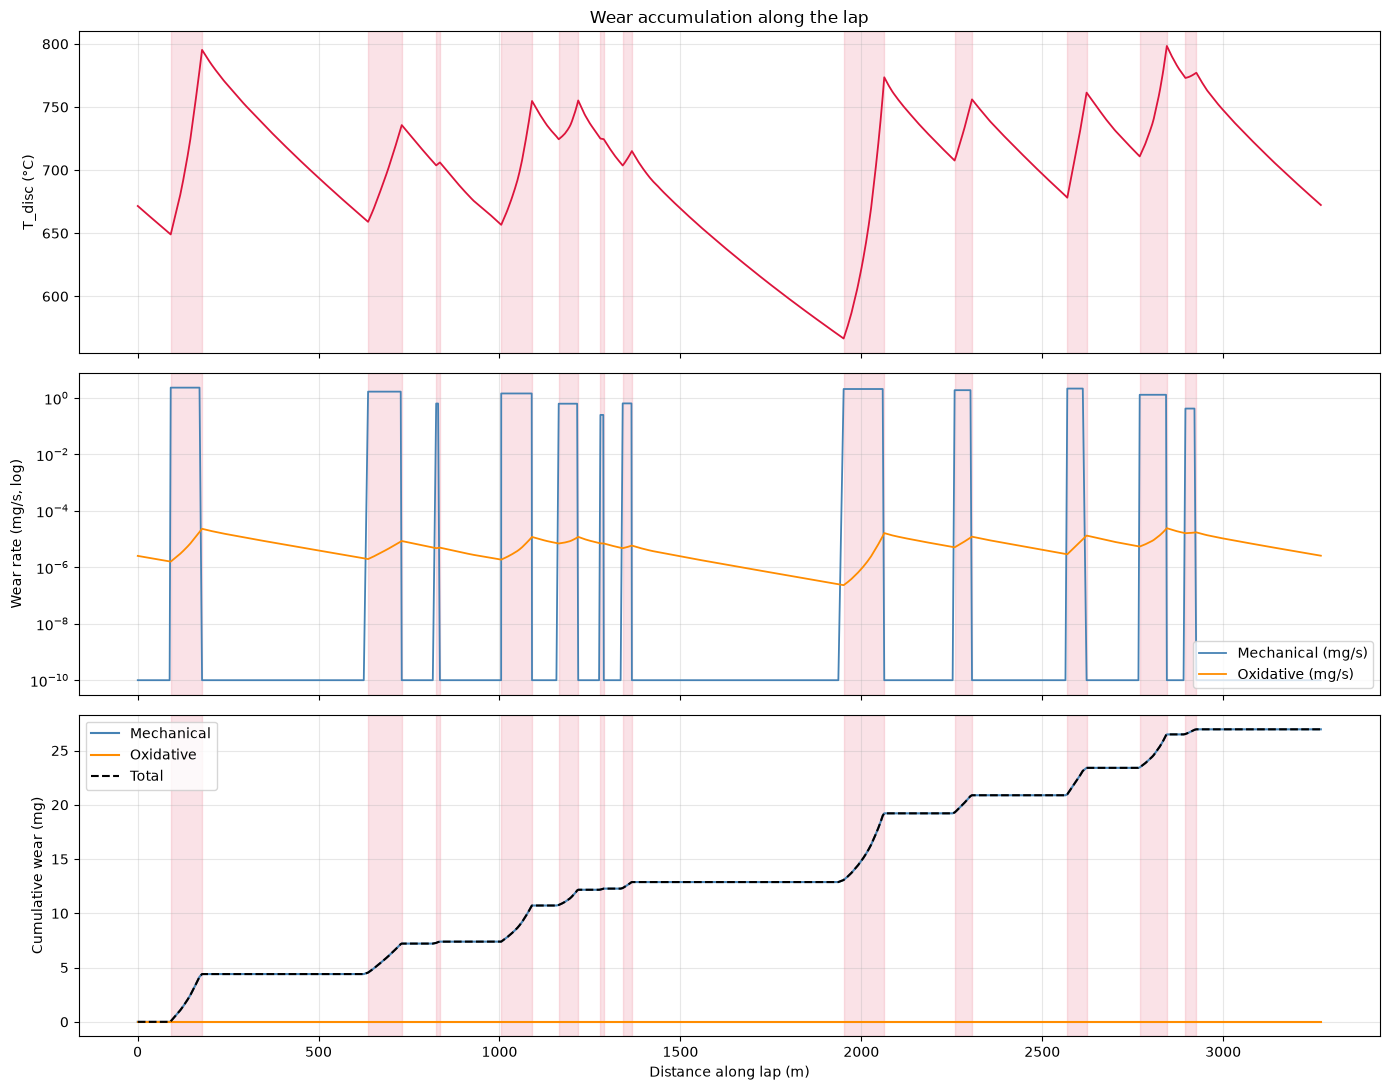

In [3]:
#Where wear concentrates on the lap

# Cumulative wear vs distance
W_cum_mech = np.concatenate([[0], np.cumsum(
    0.5 * (wear['rate_mech_kg_per_s'][:-1] + wear['rate_mech_kg_per_s'][1:])
    * np.diff(t_lap))])
W_cum_ox = np.concatenate([[0], np.cumsum(
    0.5 * (wear['rate_ox_kg_per_s'][:-1] + wear['rate_ox_kg_per_s'][1:])
    * np.diff(t_lap))])

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# Top: temperature reference
axes[0].plot(dist_lap, T_disc_C, color='crimson', linewidth=1.3)
axes[0].set_ylabel('T_disc (°C)')
axes[0].set_title('Wear accumulation along the lap')
axes[0].grid(True, alpha=0.3)
for ev in events:
    axes[0].axvspan(dist_lap[ev['start_idx']], dist_lap[ev['end_idx']],
                     color='crimson', alpha=0.12)

# Middle: instantaneous wear rates (log scale — they differ by orders of magnitude)
axes[1].semilogy(dist_lap, np.maximum(wear['rate_mech_kg_per_s'] * 1e6, 1e-10),
                  color='steelblue', linewidth=1.3, label='Mechanical (mg/s)')
axes[1].semilogy(dist_lap, np.maximum(wear['rate_ox_kg_per_s'] * 1e6, 1e-10),
                  color='darkorange', linewidth=1.3, label='Oxidative (mg/s)')
axes[1].set_ylabel('Wear rate (mg/s, log)')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3, which='both')
for ev in events:
    axes[1].axvspan(dist_lap[ev['start_idx']], dist_lap[ev['end_idx']],
                     color='crimson', alpha=0.12)

# Bottom: cumulative wear
axes[2].plot(dist_lap, W_cum_mech * 1e6, color='steelblue',
              linewidth=1.5, label='Mechanical')
axes[2].plot(dist_lap, W_cum_ox * 1e6, color='darkorange',
              linewidth=1.5, label='Oxidative')
axes[2].plot(dist_lap, (W_cum_mech + W_cum_ox) * 1e6,
              color='black', linewidth=1.5, label='Total', linestyle='--')
axes[2].set_ylabel('Cumulative wear (mg)')
axes[2].set_xlabel('Distance along lap (m)')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)
for ev in events:
    axes[2].axvspan(dist_lap[ev['start_idx']], dist_lap[ev['end_idx']],
                     color='crimson', alpha=0.12)

plt.tight_layout()
plt.show()

#What to look for:

#The mechanical wear rate (middle, blue) will be non-zero only during braking events — it's literally K_MECH × P_brake, so it's zero outside red bands.
#The oxidative wear rate (middle, orange) will be smooth and continuous, tracking disc temperature. It rises during/after each event and decays during cooling. This is the qualitative signature we wanted from the model: oxidation accumulates whenever the disc is hot, mechanical only during braking.
#The cumulative curves (bottom) will show step-like increases in mechanical (one step per event) and smooth growth in oxidative.

In [4]:
#Wear contribution per event

# Allocate mechanical wear to each event (it only happens during braking)
event_wear = []
for ev in events:
    s, e = ev['start_idx'], ev['end_idx']
    # Mechanical: integrate rate over event window
    mech_kg = np.trapezoid(wear['rate_mech_kg_per_s'][s:e+1], t_lap[s:e+1])
    # Oxidative: also report what happens during the event window
    ox_kg = np.trapezoid(wear['rate_ox_kg_per_s'][s:e+1], t_lap[s:e+1])
    event_wear.append({
        'event': ev['event_id'],
        'duration_s': t_lap[e] - t_lap[s],
        'mech_mg': mech_kg * 1e6,
        'ox_mg_during_event': ox_kg * 1e6,
    })

ew_df = pd.DataFrame(event_wear)
ew_df['mech_share_pct'] = ew_df['mech_mg'] / ew_df['mech_mg'].sum() * 100
print("Mechanical wear per event (sorted by contribution):")
print(ew_df.sort_values('mech_mg', ascending=False).to_string(index=False))

print(f"\nTotal mechanical wear over braking events: {ew_df['mech_mg'].sum():.3f} mg")
print(f"Total oxidative wear during braking events: {ew_df['ox_mg_during_event'].sum():.3f} mg")
print(f"Oxidative wear OUTSIDE braking events: "
      f"{wear['W_ox_kg']*1e6 - ew_df['ox_mg_during_event'].sum():.3f} mg")

#The last print is important: how much oxidation happens between events vs during them. At Monaco the disc spends ~80% of the lap not braking but still well above 500°C. If oxidation outside events is comparable to or larger than oxidation during events, that confirms the qualitative story: high baseline temperature is wear-relevant on its own, not just braking intensity.

Mechanical wear per event (sorted by contribution):
 event  duration_s  mech_mg  ox_mg_during_event  mech_share_pct
     8       3.057 6.142232            0.000013       23.491149
     1       1.977 4.354348            0.000017       16.653334
     4       2.316 3.326911            0.000013       12.723869
    12       2.396 3.041373            0.000030       11.631822
     2       1.617 2.670455            0.000007       10.213234
    10       1.257 2.434708            0.000009        9.311612
     9       0.880 1.588003            0.000007        6.073366
     5       2.337 1.400932            0.000021        5.357904
     7       0.880 0.552382            0.000005        2.112600
    13       1.136 0.434404            0.000019        1.661392
     3       0.238 0.113573            0.000001        0.434363
     6       0.377 0.087685            0.000003        0.335355

Total mechanical wear over braking events: 26.147 mg
Total oxidative wear during braking events: 0.000 mg
Oxidative

In [5]:
#Diagnostic check

# Where is the mechanical wear rate non-zero?
mech_nonzero_idx = np.where(wear['rate_mech_kg_per_s'] > 0)[0]
print(f"Non-zero mechanical wear samples: {len(mech_nonzero_idx)}")

# For each event, check that the samples with non-zero rate fall within the
# event's [start_idx, end_idx] inclusive range
for ev in events:
    s, e = ev['start_idx'], ev['end_idx']
    nonzero_in_event = np.sum((mech_nonzero_idx >= s) & (mech_nonzero_idx <= e))
    print(f"Event {ev['event_id']:2d}: indices [{s}, {e}] inclusive "
          f"({e - s + 1} samples), nonzero rate at {nonzero_in_event} of them")

# Are there any non-zero samples OUTSIDE any event?
in_any_event = np.zeros(len(t_lap), dtype=bool)
for ev in events:
    in_any_event[ev['start_idx']:ev['end_idx'] + 1] = True
stray = np.where((wear['rate_mech_kg_per_s'] > 0) & ~in_any_event)[0]
print(f"\nMechanical wear samples outside ANY event: {len(stray)}")
if len(stray) > 0:
    print(f"At indices: {stray[:10]}{'...' if len(stray) > 10 else ''}")

Non-zero mechanical wear samples: 134
Event  1: indices [10, 22] inclusive (13 samples), nonzero rate at 12 of them
Event  2: indices [81, 93] inclusive (13 samples), nonzero rate at 12 of them
Event  3: indices [110, 112] inclusive (3 samples), nonzero rate at 2 of them
Event  4: indices [135, 153] inclusive (19 samples), nonzero rate at 18 of them
Event  5: indices [173, 191] inclusive (19 samples), nonzero rate at 18 of them
Event  6: indices [218, 221] inclusive (4 samples), nonzero rate at 3 of them
Event  7: indices [235, 243] inclusive (9 samples), nonzero rate at 8 of them
Event  8: indices [316, 338] inclusive (23 samples), nonzero rate at 22 of them
Event  9: indices [372, 380] inclusive (9 samples), nonzero rate at 8 of them
Event 10: indices [413, 417] inclusive (5 samples), nonzero rate at 4 of them
Event 12: indices [444, 462] inclusive (19 samples), nonzero rate at 18 of them
Event 13: indices [480, 489] inclusive (10 samples), nonzero rate at 9 of them

Mechanical wear 

## Summary: what this notebook established

**Inputs:** Monaco 2026 Q pole lap steady-state thermal cycle from notebook 03
(T_mean = 715°C, T_max = 798°C, T_min = 567°C).

**Per-disc wear over the lap (with default L-confidence coefficients):**
- Mechanical: 26.95 mg (~100%)
- Oxidative: 0.001 mg (negligible at these temperatures)
- Total: ~27 mg
- Thickness loss equivalent: 0.13 µm per disc face

**Where wear concentrates:**
- Nouvelle Chicane (event 8): 23.5% of mechanical wear in a single 3-second event
- Sainte-Dévote (event 1): 16.7%
- Loews approach (event 4): 12.7%
- Top 6 events account for ~83% of mechanical wear (same energy concentration as notebook 01)

**Insight specific to Monaco qualifying:**
The oxidative mechanism is **negligible** here — peak temperature of 798°C is below the threshold where Arrhenius oxidation becomes significant. Monaco Q is a pure mechanical-wear regime. This will likely flip at higher-stress tracks (Bahrain, Singapore) and during races (longer thermal soak, higher mean temperature). The model surfaces this regime distinction explicitly.

**Engineering implication:** at Monaco Q, brake life is controlled by braking severity (driver style, energy harvest strategy), not cooling design. Cooling improvements would barely affect wear here. At hotter tracks the leverage reverses.

**Honest calibration gap:**
- Our default coefficients produce ~0.13 µm per lap; real F1 reports ~15-50 µm/lap
- Factor ~100-400× too low in absolute terms
- Relative comparisons (event vs event, mechanism vs mechanism, track vs track) remain valid
- Recalibration deferred to Phase 1b (parameter doc §5.5)

**Phase 1a physics chain now complete:**
**telemetry → energy → temperature → wear**